DATASET
Images loaded: 9604
Masks loaded:  9604
Images selected: 300 → 399
Number of images to process: 100
Noise reduction method: gaussian
Threshold: 99
Images displayed: 10


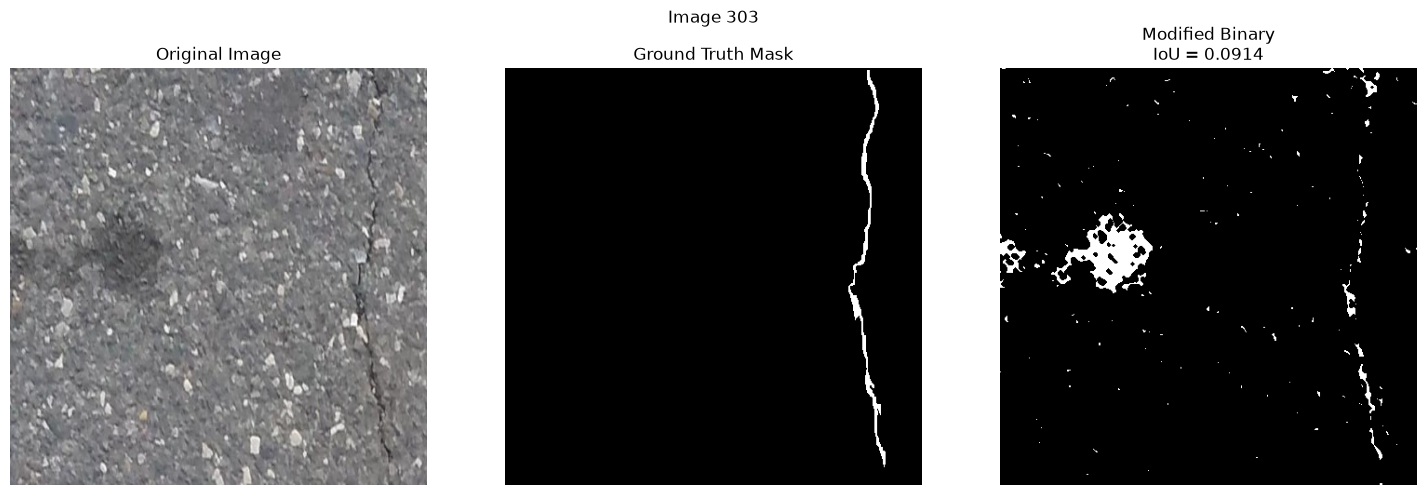

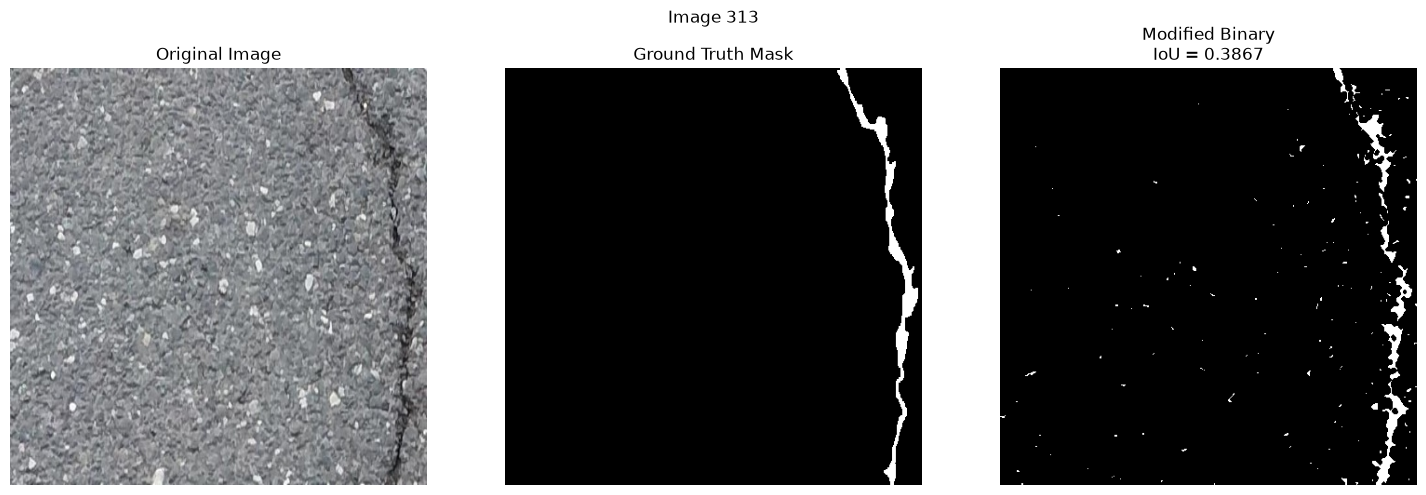

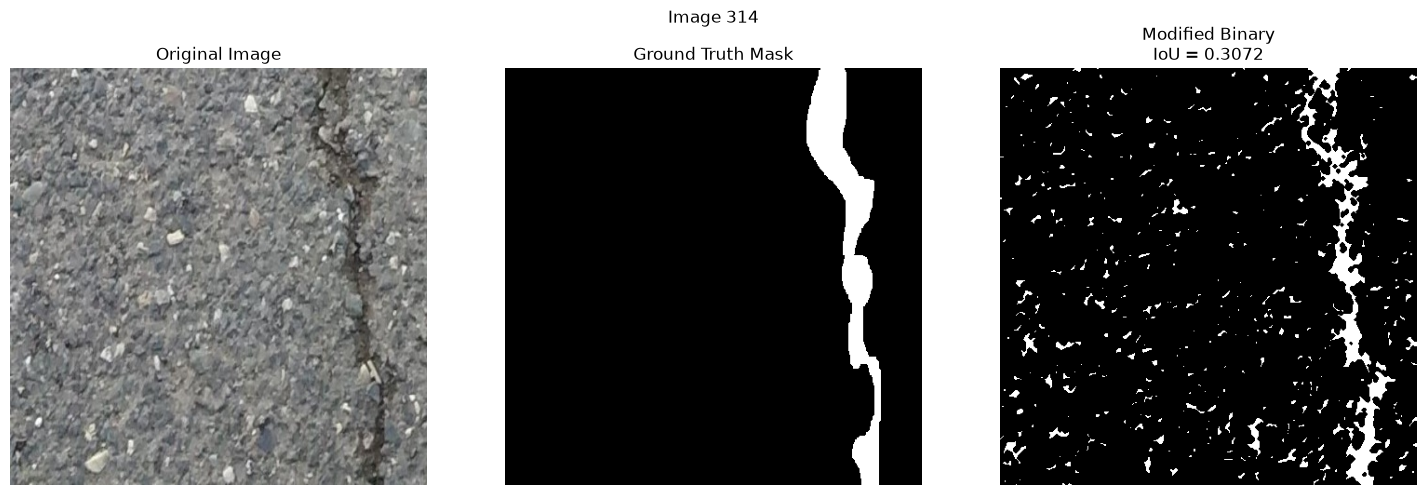

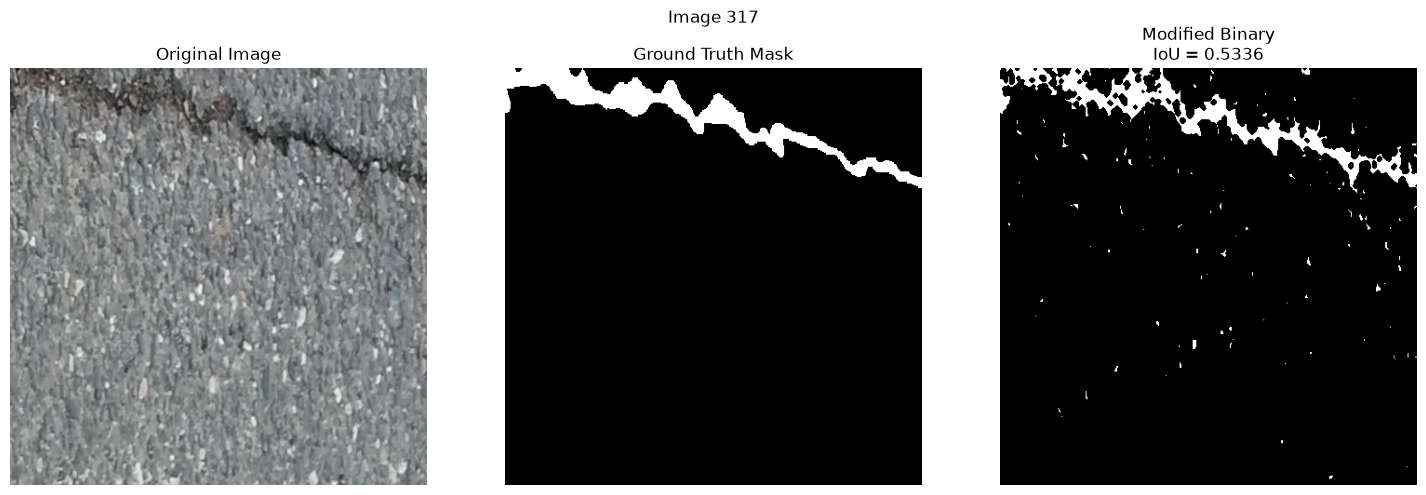

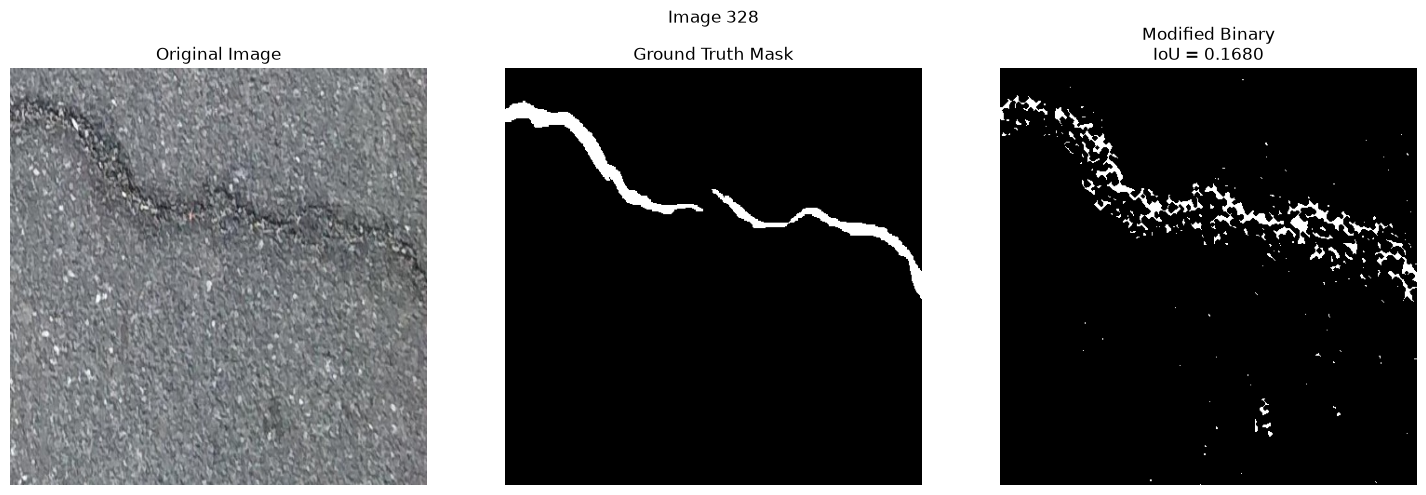

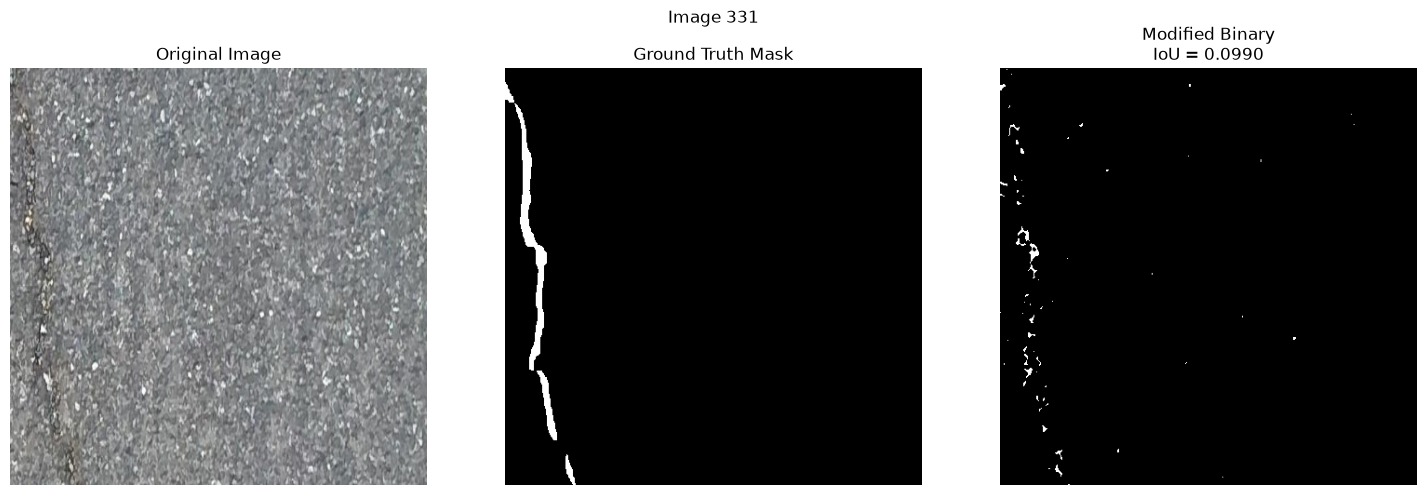

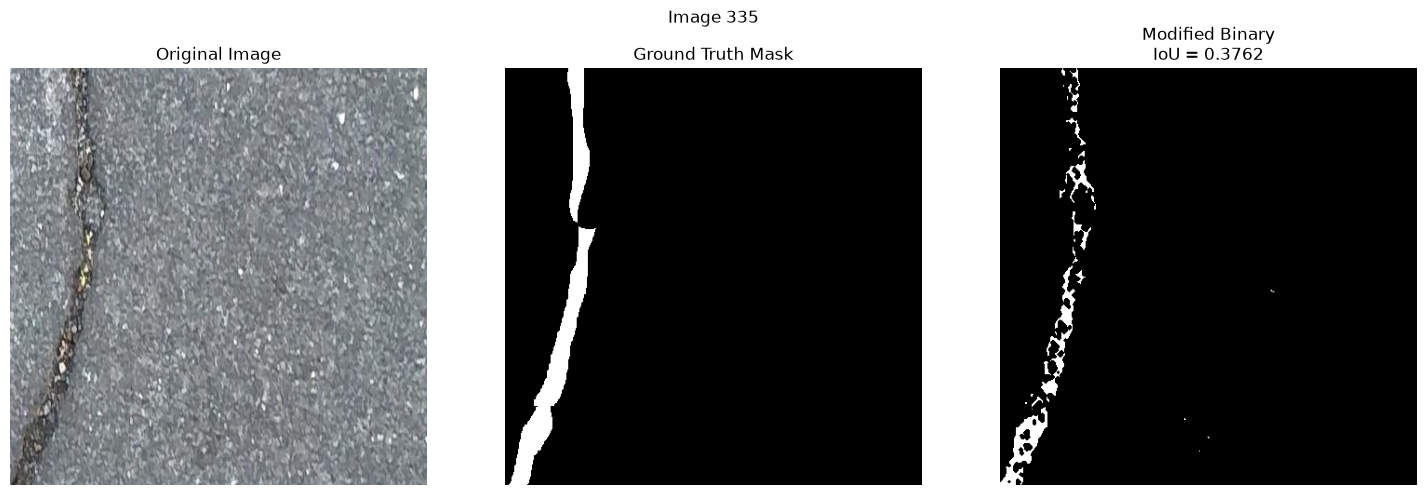

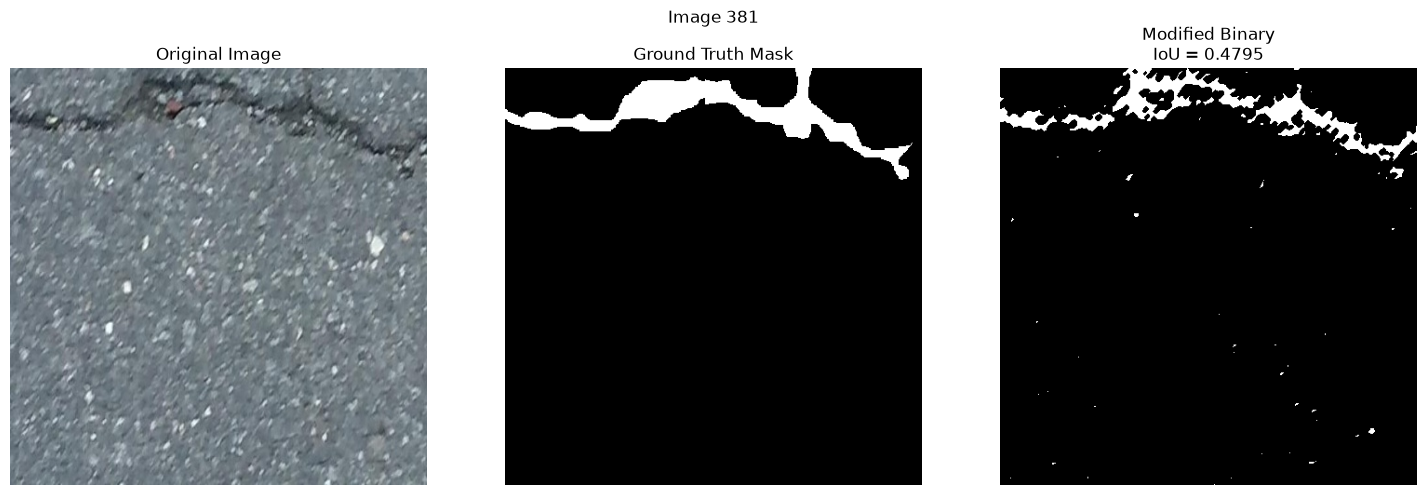

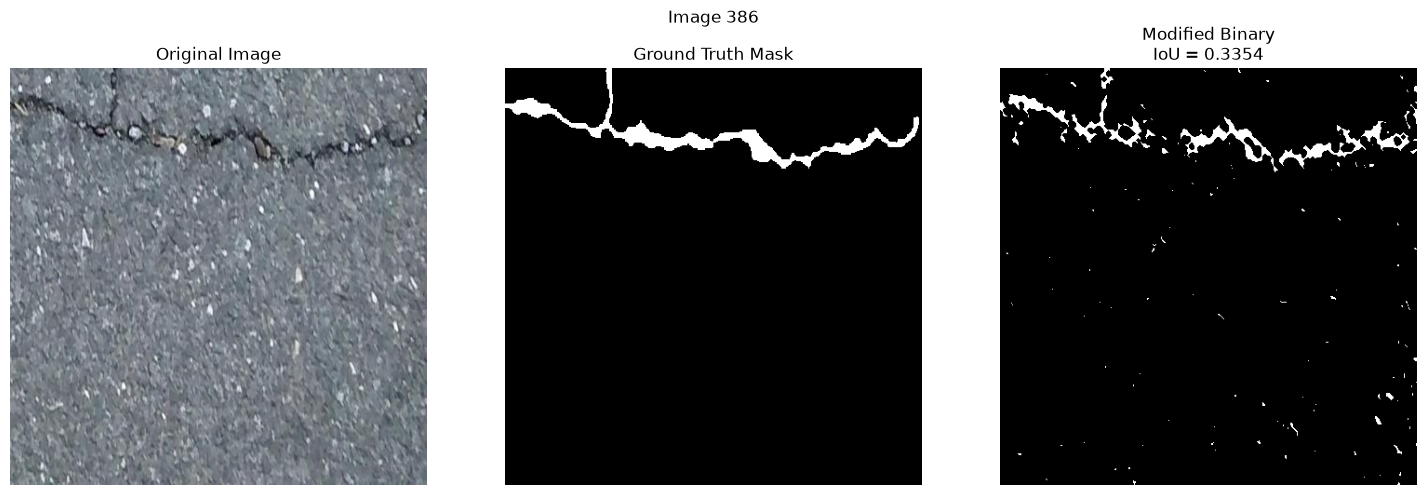

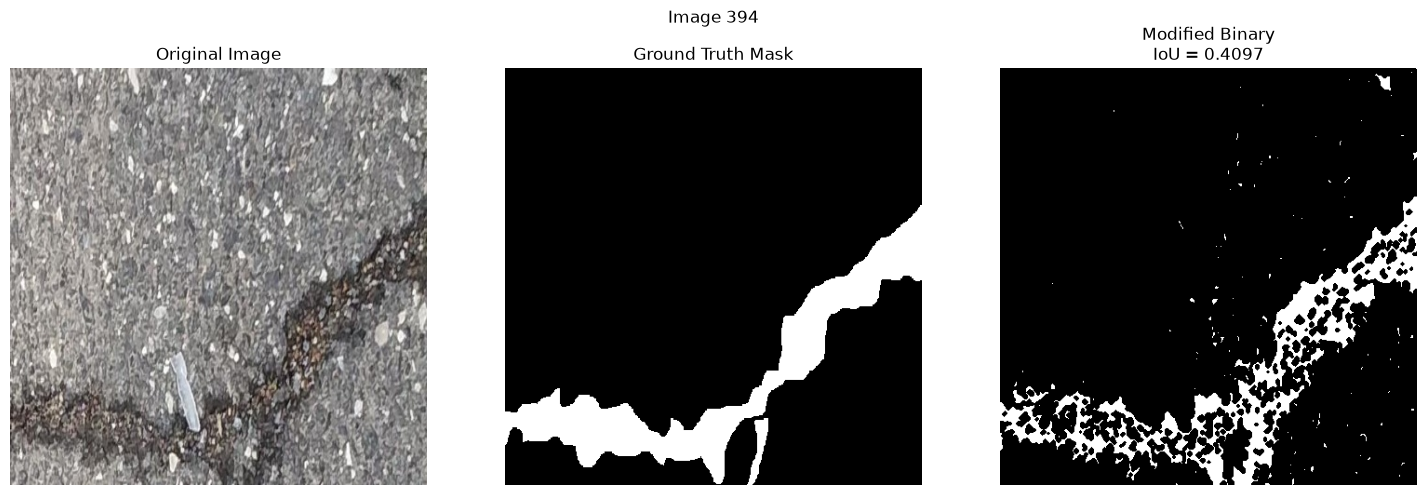



FINAL RESULTS
Images processed: 100
Average IoU: 0.3032
Average IoU: 30.32%
Best IoU: 0.5336
Best IoU: 53.36%
Best Image Index: 317
Worst IoU: 0.0335
Worst IoU: 3.35%
Worst Image Index: 307


In [1]:
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

IMAGE_FOLDER = r"\\192.168.1.10\shear all\day3\train\images\images"
MASK_FOLDER = r"\\192.168.1.10\shear all\day3\train\masks\masks"

START_INDEX = 300
END_INDEX = 400

NOISE_REDUCTION_METHOD = "gaussian"

THRESHOLD = 99

MEDIAN_KERNEL = 3

EROSION_KERNEL = 3
EROSION_ITERATIONS = 1

NUMBER_OF_IMAGES_TO_DISPLAY = 10


# ============================================================
# LOAD IMAGES AND MASKS
# ============================================================

image_paths = sorted(
    glob.glob(IMAGE_FOLDER + r"\**\*", recursive=True)
)

mask_paths = sorted(
    glob.glob(MASK_FOLDER + r"\**\*", recursive=True)
)


images = [
    cv2.imread(path)
    for path in image_paths
]

masks = [
    cv2.imread(path)
    for path in mask_paths
]


print("=" * 70)
print("DATASET")
print("=" * 70)

print(f"Images loaded: {len(images)}")
print(f"Masks loaded:  {len(masks)}")


# ============================================================
# CHECK DATASET
# ============================================================

if len(images) != len(masks):

    raise ValueError(
        "Number of images and masks do not match."
    )


if len(images) < END_INDEX:

    raise ValueError(
        f"Dataset contains only {len(images)} images."
    )


# ============================================================
# NOISE REDUCTION FUNCTION
# ============================================================

def noise_reduction(gray, method="gaussian"):

    if method == "gaussian":

        return cv2.GaussianBlur(
            gray,
            (5, 5),
            0
        )

    elif method == "median":

        return cv2.medianBlur(
            gray,
            5
        )

    elif method == "bilateral":

        return cv2.bilateralFilter(
            gray,
            9,
            75,
            75
        )

    else:

        raise ValueError(
            f"Unknown noise reduction method: {method}"
        )


# ============================================================
# SELECT IMAGE RANGE
# ============================================================

selected_images = images[START_INDEX:END_INDEX]
selected_masks = masks[START_INDEX:END_INDEX]


print(
    f"Images selected: "
    f"{START_INDEX} → {END_INDEX - 1}"
)

print(
    f"Number of images to process: "
    f"{len(selected_images)}"
)

print(
    f"Noise reduction method: "
    f"{NOISE_REDUCTION_METHOD}"
)

print(
    f"Threshold: "
    f"{THRESHOLD}"
)


# ============================================================
# SELECT 10 IMAGES FOR DISPLAY
# ============================================================

random.seed(42)

display_positions = random.sample(
    range(len(selected_images)),
    NUMBER_OF_IMAGES_TO_DISPLAY
)


print(
    f"Images displayed: "
    f"{NUMBER_OF_IMAGES_TO_DISPLAY}"
)


# ============================================================
# STORE IoU VALUES
# ============================================================

iou_values = []
image_indices = []


# ============================================================
# PROCESS ALL SELECTED IMAGES
# ============================================================

for position, (image, mask) in enumerate(
    zip(selected_images, selected_masks)
):

    image_number = START_INDEX + position


    # --------------------------------------------------------
    # 1. GRAYSCALE
    # --------------------------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # --------------------------------------------------------
    # 2. NOISE REDUCTION
    # --------------------------------------------------------

    filtered_gray = noise_reduction(
        gray,
        method=NOISE_REDUCTION_METHOD
    )


    # --------------------------------------------------------
    # 3. SIMPLE THRESHOLD
    # --------------------------------------------------------

    _, binary = cv2.threshold(
        filtered_gray,
        THRESHOLD,
        255,
        cv2.THRESH_BINARY_INV
    )


    # --------------------------------------------------------
    # 4. MEDIAN FILTER
    # --------------------------------------------------------

    median_binary = cv2.medianBlur(
        binary,
        MEDIAN_KERNEL
    )


    # --------------------------------------------------------
    # 5. EROSION
    # --------------------------------------------------------

    erosion_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            EROSION_KERNEL,
            EROSION_KERNEL
        )
    )

    eroded = cv2.erode(
        median_binary,
        erosion_kernel,
        iterations=EROSION_ITERATIONS
    )


    # --------------------------------------------------------
    # 6. GROUND TRUTH MASK
    # --------------------------------------------------------

    if len(mask.shape) == 3:

        mask_gray = cv2.cvtColor(
            mask,
            cv2.COLOR_BGR2GRAY
        )

    else:

        mask_gray = mask


    _, mask_binary = cv2.threshold(
        mask_gray,
        127,
        255,
        cv2.THRESH_BINARY
    )


    # --------------------------------------------------------
    # 7. CALCULATE IoU
    # --------------------------------------------------------

    TP = np.logical_and(
        mask_binary == 255,
        eroded == 255
    ).sum()

    FP = np.logical_and(
        mask_binary == 0,
        eroded == 255
    ).sum()

    FN = np.logical_and(
        mask_binary == 255,
        eroded == 0
    ).sum()


    denominator = TP + FP + FN


    if denominator > 0:

        IoU = TP / denominator

    else:

        IoU = 0


    # --------------------------------------------------------
    # STORE RESULT
    # --------------------------------------------------------

    iou_values.append(IoU)
    image_indices.append(image_number)


    # ========================================================
    # DISPLAY ONLY 10 IMAGES
    # ========================================================

    if position in display_positions:

        plt.figure(figsize=(15, 5))


        # ----------------------------------------------------
        # ORIGINAL IMAGE
        # ----------------------------------------------------

        plt.subplot(1, 3, 1)

        plt.imshow(
            cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title("Original Image")
        plt.axis("off")


        # ----------------------------------------------------
        # GROUND TRUTH MASK
        # ----------------------------------------------------

        plt.subplot(1, 3, 2)

        plt.imshow(
            mask_binary,
            cmap="gray"
        )

        plt.title("Ground Truth Mask")
        plt.axis("off")


        # ----------------------------------------------------
        # FINAL BINARY
        # ----------------------------------------------------

        plt.subplot(1, 3, 3)

        plt.imshow(
            eroded,
            cmap="gray"
        )

        plt.title(
            f"Modified Binary\nIoU = {IoU:.4f}"
        )

        plt.axis("off")


        plt.suptitle(
            f"Image {image_number}"
        )

        plt.tight_layout()
        plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

average_iou = np.mean(iou_values)

best_position = np.argmax(iou_values)
worst_position = np.argmin(iou_values)

best_iou = iou_values[best_position]
worst_iou = iou_values[worst_position]

best_image_index = image_indices[best_position]
worst_image_index = image_indices[worst_position]


# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"Images processed: "
    f"{len(iou_values)}"
)

print(
    f"Average IoU: "
    f"{average_iou:.4f}"
)

print(
    f"Average IoU: "
    f"{average_iou * 100:.2f}%"
)

print(
    f"Best IoU: "
    f"{best_iou:.4f}"
)

print(
    f"Best IoU: "
    f"{best_iou * 100:.2f}%"
)

print(
    f"Best Image Index: "
    f"{best_image_index}"
)

print(
    f"Worst IoU: "
    f"{worst_iou:.4f}"
)

print(
    f"Worst IoU: "
    f"{worst_iou * 100:.2f}%"
)

print(
    f"Worst Image Index: "
    f"{worst_image_index}"
)

print("=" * 70)
